In [ ]:
# @title 1. Setup Environment
# Install required libraries
!pip install -qq diffusers transformers accelerate pillow torch torchvision

import torch
from diffusers import StableDiffusionInpaintPipeline
from PIL import Image
import numpy as np
import io
from google.colab import files
from IPython.display import display

# Check for GPU and set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print("Libraries installed and loaded successfully.")

# NOTE: If you are using a gated model (like Stable Diffusion 2.1),
# you might need to uncomment and run the following lines to log in to Hugging Face:
# from huggingface_hub import notebook_login
# notebook_login()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda
Libraries installed and loaded successfully.


In [ ]:
# @title 2. Load Stable Diffusion Inpainting Model
# We use the Stable Diffusion 1.5 inpainting model for stability and speed.
# For higher quality, you could try 'stabilityai/stable-diffusion-2-inpainting'
# or 'diffusers/stable-diffusion-xl-1.0-inpainting-0.1' (requires more VRAM).

MODEL_ID = "runwayml/stable-diffusion-inpainting"

print(f"Loading model: {MODEL_ID}. This may take a few minutes...")

# Load the pipeline, enabling half-precision (float16) for faster inference on GPU
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)
# Add this right after .to(device)
if device == "cuda":
    pipe.enable_attention_slicing()

print("Model loaded successfully into memory.")


Loading model: runwayml/stable-diffusion-inpainting. This may take a few minutes...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--r

Model loaded successfully into memory.


--- Upload Original Image ---
Please upload the base image (e.g., 'photo.jpg').


Saving messi.png to messi.png

Original Image loaded (messi.png):


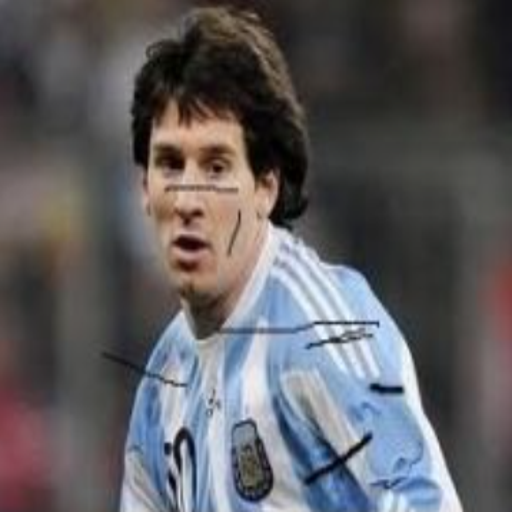

In [ ]:
# @title 3a. Upload Original Image
# Upload the base image you want to modify.

print("--- Upload Original Image ---")
print("Please upload the base image (e.g., 'photo.jpg').")

uploaded_img = files.upload()

# Get the filename and load the image
if uploaded_img:
    initial_image_file = list(uploaded_img.keys())[0]
    # Load and resize to 512x512, converting to RGB
    init_image = Image.open(io.BytesIO(uploaded_img[initial_image_file])).convert("RGB").resize((512, 512))

    # Display Input
    print(f"\nOriginal Image loaded ({initial_image_file}):")
    display(init_image)
else:
    print("Error: No original image uploaded. Please run the cell again.")


--- Upload Mask Image ---
Please upload the mask image (e.g., 'mask.png').


Saving mask.png to mask.png

Mask Image loaded (mask.png) - White area will be replaced:


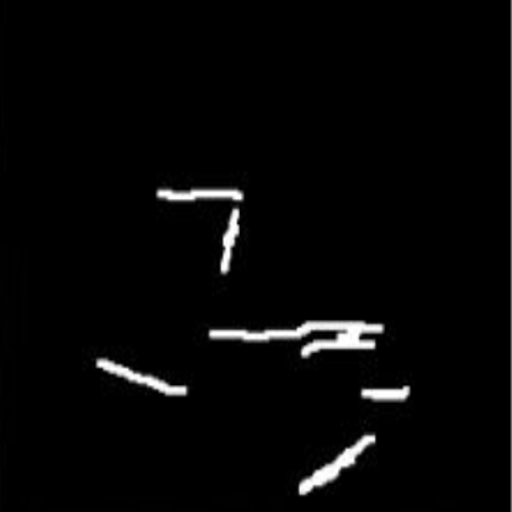

In [ ]:
# @title 3b. Upload Mask Image
# Upload the mask image defining the area to be replaced.
# NOTE: The mask must be a black and white image where the WHITE area (255)
# is the region that will be INPAINTED.

print("\n--- Upload Mask Image ---")
print("Please upload the mask image (e.g., 'mask.png').")

uploaded_mask = files.upload()

# Get the filename and load the mask
if uploaded_mask:
    mask_image_file = list(uploaded_mask.keys())[0]
    # Load and resize to 512x512, converting to Grayscale ('L')
    mask_image = Image.open(io.BytesIO(uploaded_mask[mask_image_file])).convert("L").resize((512, 512))

    # Display Input
    print(f"\nMask Image loaded ({mask_image_file}) - White area will be replaced:")
    display(mask_image)
else:
    print("Error: No mask image uploaded. Please run the cell again.")

In [ ]:
# @title 4. Define Parameters and Run Inpainting
# Edit the PROMPT below to describe what you want generated in the masked area.

# --- A. Define Text Prompts ---
# MODIFIED PROMPT: Focuses on realistic photo restoration of Lionel Messi.
PROMPT = "photorealistic restoration, high quality, detailed, natural lighting" # @param {type:"string"}
NEGATIVE_PROMPT = "blurry, low quality, deformed, worst quality, extra limbs, simple, scratches, lines, digital art, cartoon" # @param {type:"string"}

# --- B. Define Generative Parameters ---
GUIDANCE_SCALE = 7.5    # @param {type:"number"} # Classifier-Free Guidance: Higher value means the model follows the PROMPT more strictly. (Typically 7.0 - 9.0)
NUM_INFERENCE_STEPS = 50 # @param {type:"slider", min:20, max:100, step:10} # Quality/time trade-off: Higher steps improve detail but slow down generation.
SEED = 42                # @param {type:"number"} # Use a fixed number for reproducible results. Change this to explore different results.

print(f"\n--- Running Inpainting with Prompt: '{PROMPT}' ---")
print(f"Inference Steps: {NUM_INFERENCE_STEPS}, Guidance Scale: {GUIDANCE_SCALE}")

# Set the generator for reproducibility
generator = torch.Generator(device=device).manual_seed(SEED)

# --- EXECUTION: The Stable Diffusion Inpainting Call ---
# This executes the diffusion process, filling in the masked area based on the prompt.
inpainted_image = pipe(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    image=init_image,
    mask_image=mask_image,
    guidance_scale=GUIDANCE_SCALE,
    num_inference_steps=NUM_INFERENCE_STEPS,
    generator=generator
).images[0]

print("Inpainting complete.")


--- Running Inpainting with Prompt: 'photorealistic restoration, high quality, detailed, natural lighting' ---
Inference Steps: 50, Guidance Scale: 7.5


  0%|          | 0/50 [00:00<?, ?it/s]

Inpainting complete.


/tmp/ipykernel_3815/2687715921.py:19: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


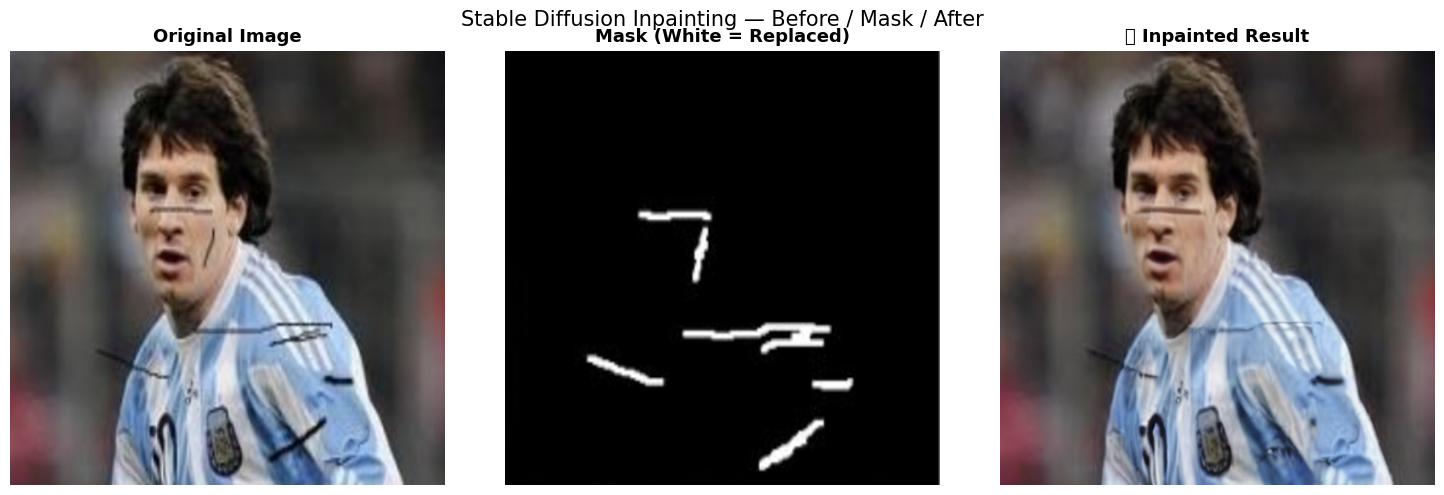

✅ Saved as 'inpainted_result.png'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title 5. Display and Save Final Result
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(init_image)
axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mask_image, cmap='gray')
axes[1].set_title("Mask (White = Replaced)", fontsize=13, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(inpainted_image)
axes[2].set_title("✨ Inpainted Result", fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle("Stable Diffusion Inpainting — Before / Mask / After", fontsize=15)
plt.tight_layout()
plt.show()

# Save and auto-download
output_filename = "inpainted_result.png"
inpainted_image.save(output_filename)
print(f"✅ Saved as '{output_filename}'")
files.download(output_filename)